# Building Product Recommendation Systems Using Real-World Retail and Gaming Data

## Exploratory Analysis and Predictive Modeling

This notebook integrates Amazon reviews, Steam user interactions, and global video game sales data to investigate the factors associated with product success and user engagement.

The analysis focuses on identifying key engagement and sentiment signals and evaluating predictive models for sales outcomes.

## Load Cleaned Datasets

The cleaned datasets are not included in this repository because of their size.

Update the file paths below to match your local data directory before running the notebook.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Update "path_to_data" to the location of the cleaned datasets
amazon_df = pd.read_parquet("path_to_data/amazon_clean.parquet")
steam_df = pd.read_parquet("path_to_data/steam_clean.parquet")
sales_df = pd.read_parquet("path_to_data/sales_clean.parquet")

print("Amazon shape:", amazon_df.shape)
print("Steam shape:", steam_df.shape)
print("Sales shape:", sales_df.shape)

Amazon shape: (1038, 19)
Steam shape: (10899024, 20)
Sales shape: (19415, 17)


## Exploratory Data Analysis (EDA)



#Amazon Product Reviews

In [6]:



amazon_df = pd.read_parquet("/content/amazon_clean.parquet")

amazon_df.info()
amazon_df.head()

print("Missing values:")
print(amazon_df.isnull().sum())

print("Duplicate rows:")
print(amazon_df.duplicated().sum())

amazon_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1038 entries, 0 to 1037
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   1038 non-null   object 
 1   asins                1038 non-null   object 
 2   brand                1038 non-null   object 
 3   categories           1038 non-null   object 
 4   colors               1038 non-null   object 
 5   dateAdded            1038 non-null   object 
 6   dateUpdated          1038 non-null   object 
 7   dimension            1038 non-null   object 
 8   keys                 1038 non-null   object 
 9   manufacturer         1038 non-null   object 
 10  manufacturerNumber   1038 non-null   object 
 11  name                 1038 non-null   object 
 12  prices               1038 non-null   object 
 13  reviews.date         1038 non-null   object 
 14  reviews.doRecommend  1038 non-null   object 
 15  reviews.numHelpful   1038 non-null   f

,reviews.numHelpful,reviews.rating
count,1038.000000,1038.000000
mean,72.458574,4.370906
std,185.751619,1.032827
min,0.000000,1.000000
25%,0.000000,4.000000
50%,0.000000,5.000000
75%,16.000000,5.000000
max,997.000000,5.000000


#Distribution of Ratings

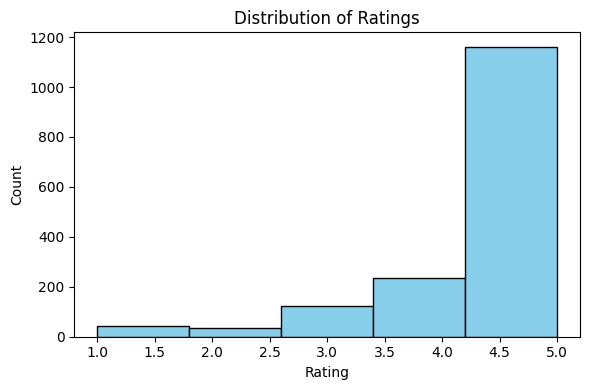

In [ ]:
# Distribution of Ratings
plt.figure(figsize=(6,4))

plt.hist(
    amazon_df['reviews.rating'],
    bins=5,
    color='skyblue',
    edgecolor='black'
)

plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Distribution of Ratings')

plt.tight_layout()
plt.savefig('fig1_ratings_hist.png', dpi=300)
plt.show()

The distribution of review ratings shows that customer feedback is generally positive, with most reviews receiving high ratings. Lower ratings represent a smaller proportion of observations, indicating that the dataset is imbalanced toward positive customer experiences. This concentration of high ratings should be considered when developing predictive models, as distinguishing between highly rated products may be more challenging.

#Helpful Reviews

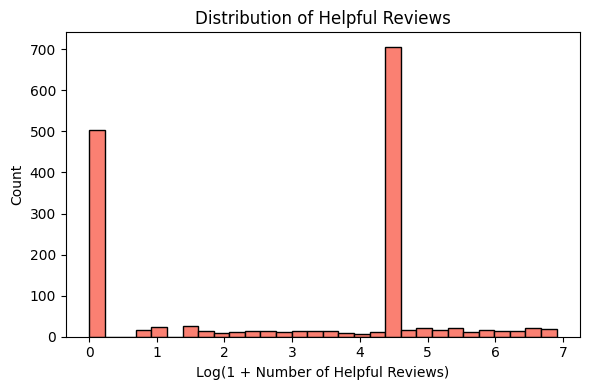

In [ ]:


# Distribution of Helpful Reviews (log scale)
plt.figure(figsize=(6,4))

plt.hist(
    np.log1p(amazon_df['reviews.numHelpful']),
    bins=30,
    color='salmon',
    edgecolor='black'
)

plt.xlabel('Log(1 + Number of Helpful Reviews)')
plt.ylabel('Count')
plt.title('Distribution of Helpful Reviews')

plt.tight_layout()
plt.savefig('fig2_helpful_reviews_hist.png', dpi=300)
plt.show()

The number of helpful votes is highly skewed, with most reviews receiving relatively few helpful votes and a small number of reviews receiving substantially higher engagement. Applying a logarithmic transformation reduces the impact of extreme values and provides a clearer view of review interaction patterns. This suggests that review engagement varies significantly across products and may provide useful signals for understanding customer behavior.

#Recommendation Trends

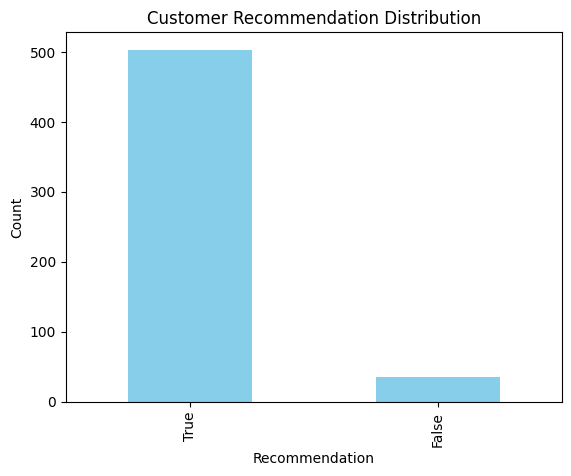

In [ ]:
amazon_df['reviews.doRecommend'].value_counts().plot(
    kind='bar',
    color='skyblue'
)

plt.xlabel('Recommendation')
plt.ylabel('Count')
plt.title('Customer Recommendation Distribution')
plt.show()

The recommendation distribution shows that most available customer recommendations are positive, indicating strong customer satisfaction among reviewed products. However, the large number of missing recommendation values limits its use as a standalone indicator. This feature may still provide useful information for understanding customer preferences and predicting product success.

#Correlation Heatmap

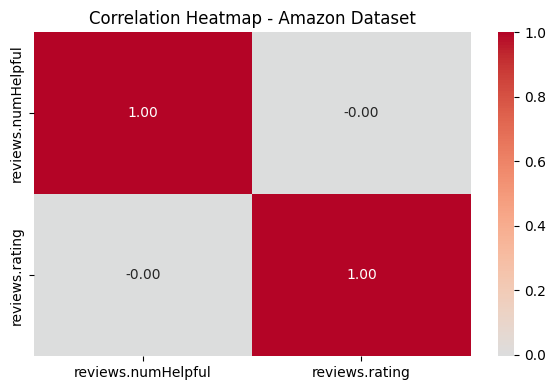

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load cleaned Amazon dataset
amazon_df = pd.read_parquet("/content/amazon_clean.parquet")

# Select numeric columns only
numeric_df = amazon_df.select_dtypes(include=['number'])

# Compute correlations
corr_amazon = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_amazon,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Heatmap - Amazon Dataset")
plt.tight_layout()
plt.show()

The correlation analysis shows the relationships between numerical variables in the Amazon dataset. Review ratings and helpful review counts show limited linear correlation, suggesting that review quality and customer engagement capture different aspects of user behavior. Additional text-based and categorical features may provide more predictive information for modeling customer feedback.

#Ratings by Top 10 Categories/Brands

/tmp/ipykernel_485/964556478.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


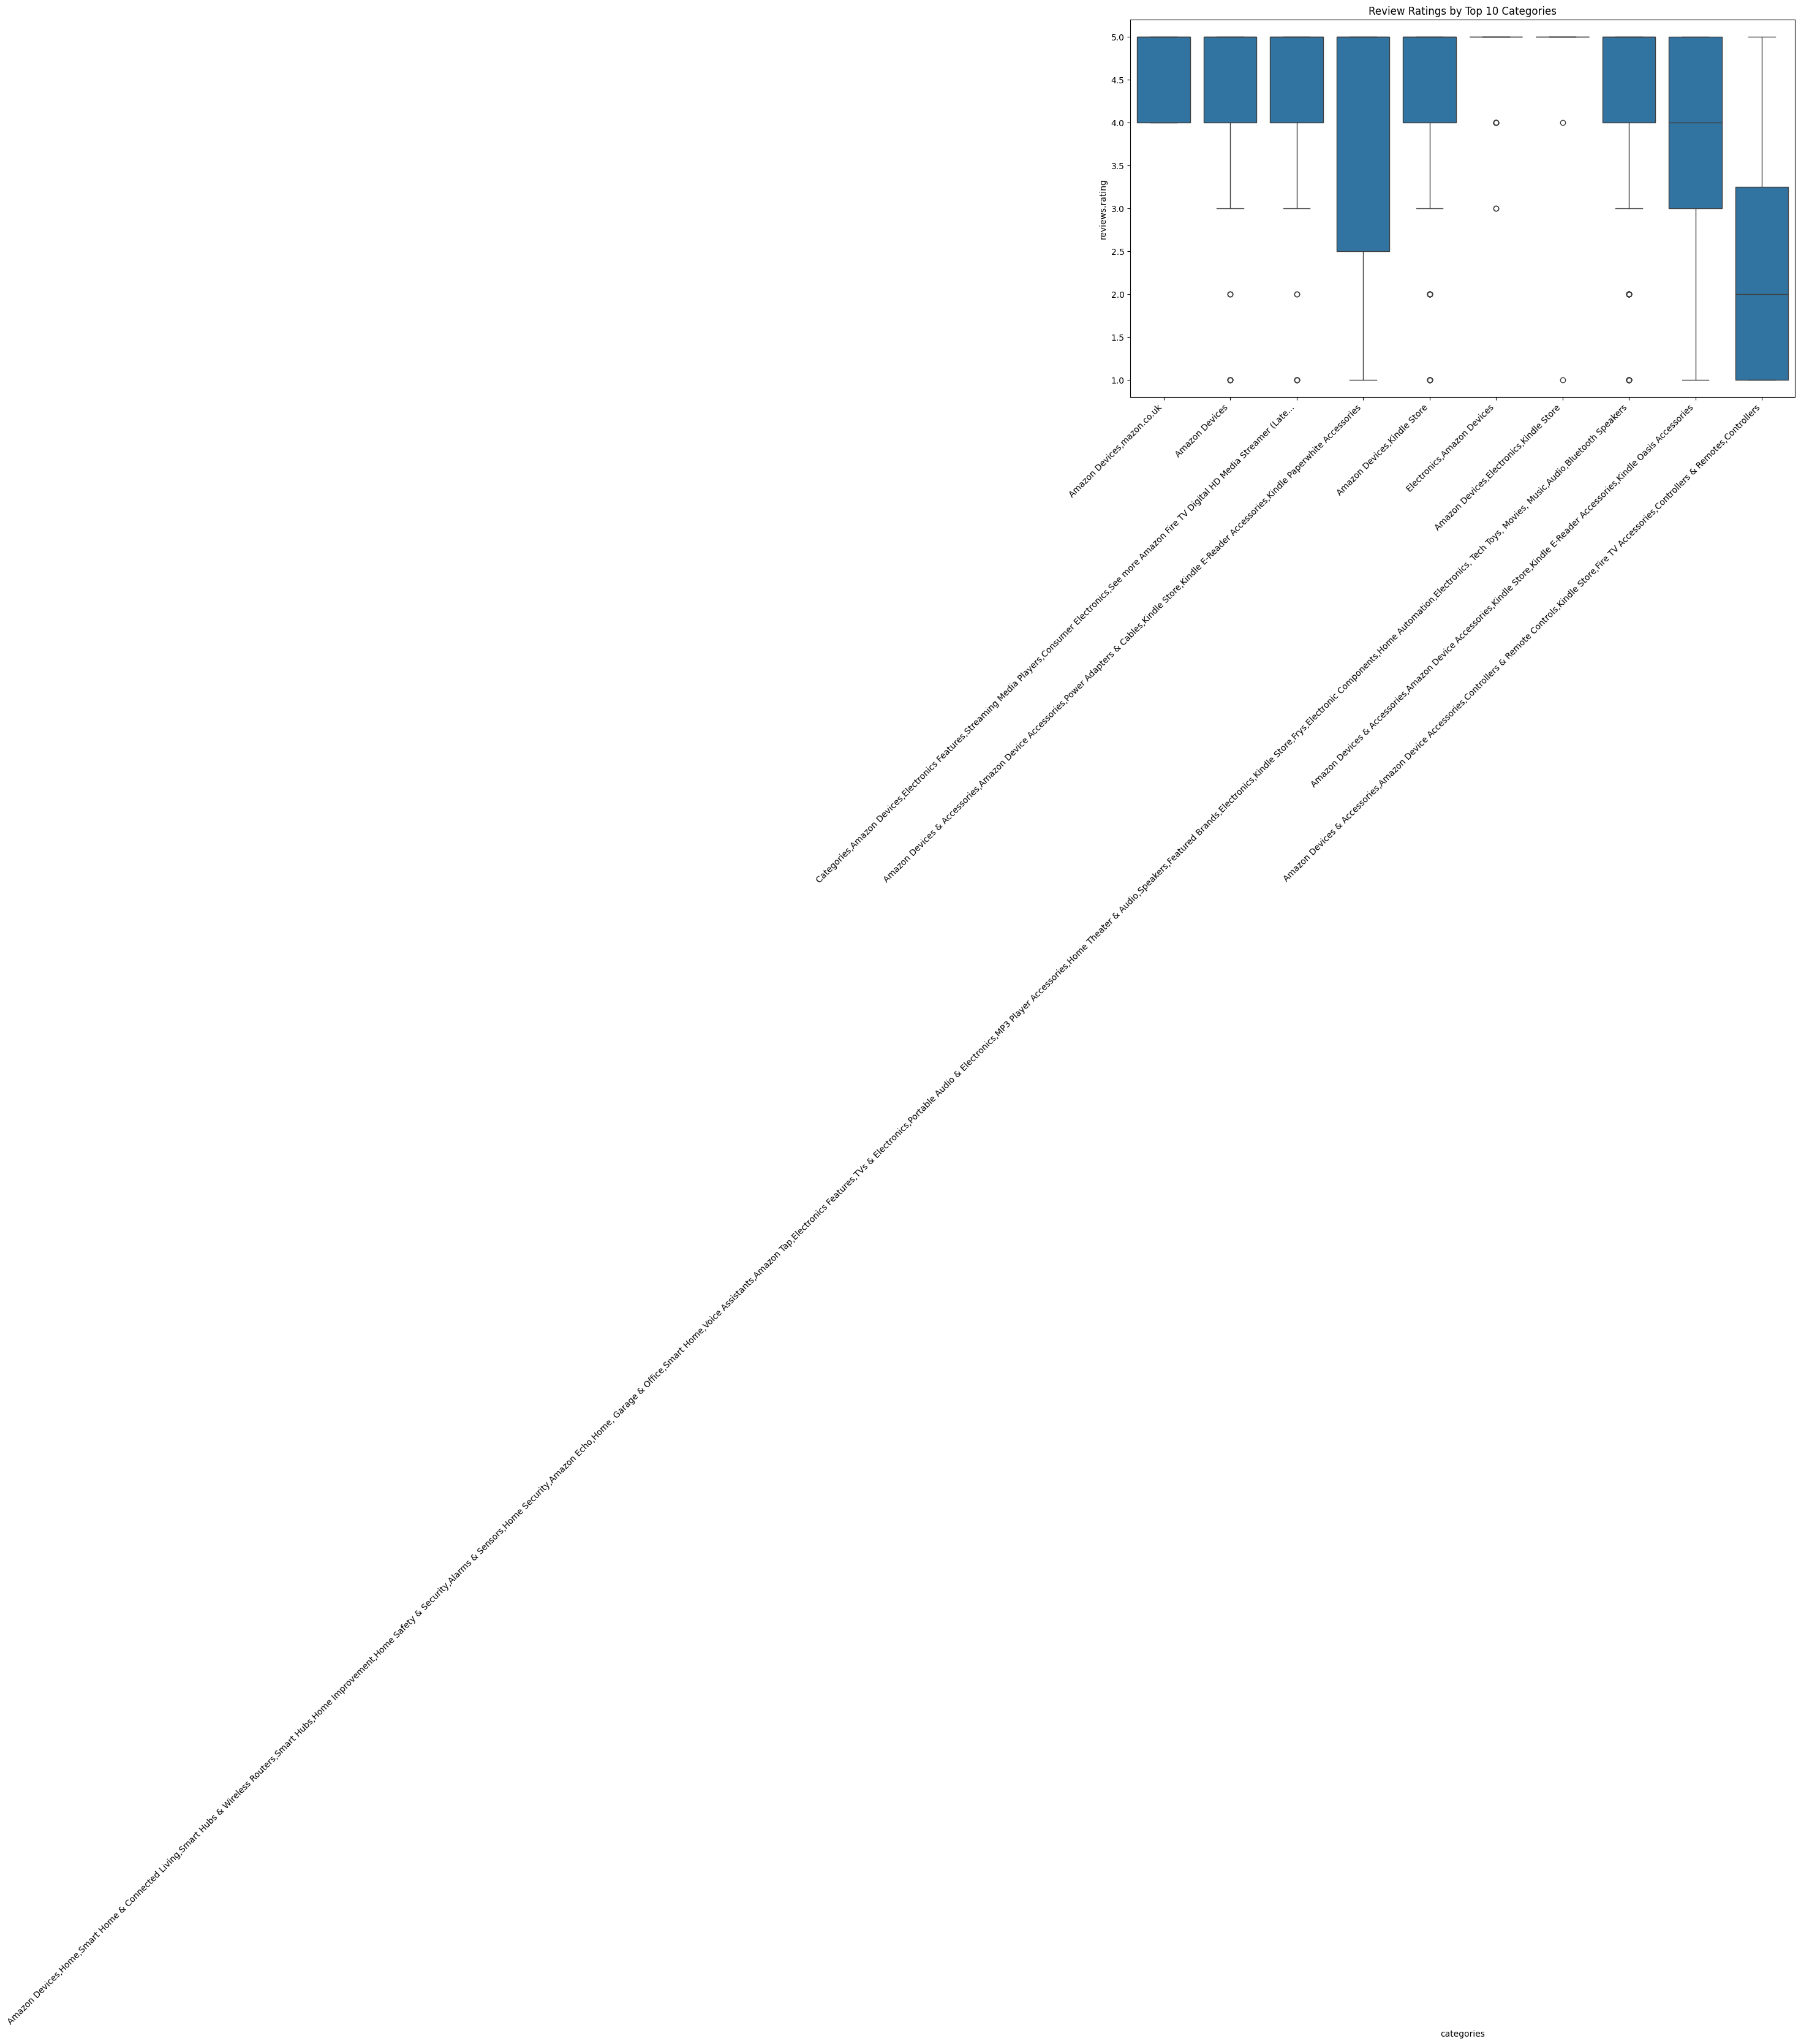

In [22]:
top_categories = amazon_df['categories'].value_counts().head(10).index

amazon_top = amazon_df[amazon_df['categories'].isin(top_categories)]

plt.figure(figsize=(14,8))

sns.boxplot(
    x='categories',
    y='reviews.rating',
    data=amazon_top
)

plt.xticks(rotation=45, ha='right')
plt.title('Review Ratings by Top 10 Categories')

plt.tight_layout()
plt.show()

Review ratings remain relatively high across the most frequent product categories, although some variation exists between categories. This suggests that product category may have some influence on customer satisfaction, but other factors such as product quality, brand, and customer expectations may also contribute to rating differences.

#STEAM

In [7]:

steam_df = pd.read_parquet("steam_clean.parquet")

steam_df.info()

print("Missing values:")
print(steam_df.isnull().sum())

print("Duplicate rows:")
print(steam_df.duplicated().sum())

steam_df.describe()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10899024 entries, 0 to 10899023
Data columns (total 20 columns):
 #   Column          Dtype  
---  ------          -----  
 0   app_id          int64  
 1   helpful         int64  
 2   funny           int64  
 3   date            object 
 4   is_recommended  int64  
 5   hours           float64
 6   products        float64
 7   reviews         float64
 8   title           object 
 9   date_release    object 
 10  win             bool   
 11  mac             bool   
 12  linux           bool   
 13  rating          object 
 14  positive_ratio  float64
 15  user_reviews    float64
 16  price_final     float64
 17  price_original  float64
 18  discount        float64
 19  steam_deck      bool   
dtypes: bool(4), float64(8), int64(4), object(4)
memory usage: 1.3+ GB
Missing values:
app_id            0
helpful           0
funny             0
date              0
is_recommended    0
hours             0
products          0
reviews           0


,app_id,helpful,funny,is_recommended,hours,products,reviews,positive_ratio,user_reviews,price_final,price_original,discount
count,1.089902e+07,1.089902e+07,1.089902e+07,1.089902e+07,1.089902e+07,1.089902e+07,1.089902e+07,1.089902e+07,1.089902e+07,1.089902e+07,1.089902e+07,1.089902e+07
mean,6.195183e+05,3.391713e+00,1.203466e+00,8.556795e-01,1.548618e+02,1.984181e+02,1.053981e+01,8.700770e+01,3.270767e+05,2.354644e+01,3.967677e+00,1.098165e+00
std,4.821327e+05,5.705197e+01,3.935662e+01,3.514145e-01,2.130974e+02,3.915952e+02,4.091078e+01,9.273616e+00,9.689293e+05,1.757871e+01,1.057840e+01,8.571267e+00
min,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,3.700000e+01,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.620600e+05,0.000000e+00,0.000000e+00,1.000000e+00,1.890000e+01,3.900000e+01,1.000000e+00,8.300000e+01,3.838600e+04,1.000000e+01,0.000000e+00,0.000000e+00
50%,4.319600e+05,0.000000e+00,0.000000e+00,1.000000e+00,6.070000e+01,9.800000e+01,3.000000e+00,8.900000e+01,9.391000e+04,2.000000e+01,0.000000e+00,0.000000e+00
75%,1.049590e+06,0.000000e+00,0.000000e+00,1.000000e+00,1.938000e+02,2.220000e+02,9.000000e+00,9.400000e+01,2.069390e+05,3.999000e+01,0.000000e+00,0.000000e+00
max,2.208920e+06,3.621200e+04,2.367400e+04,1.000000e+00,9.999000e+02,3.221400e+04,6.045000e+03,9.900000e+01,7.494460e+06,7.999000e+01,7.999000e+01,9.000000e+01


In [ ]:
steam_df['rating'].value_counts()

,count
rating,
Very Positive,4051669
Overwhelmingly Positive,1587856
Mostly Positive,817570
Mixed,403148
Positive,4


#Distribution of Steam Review Ratings

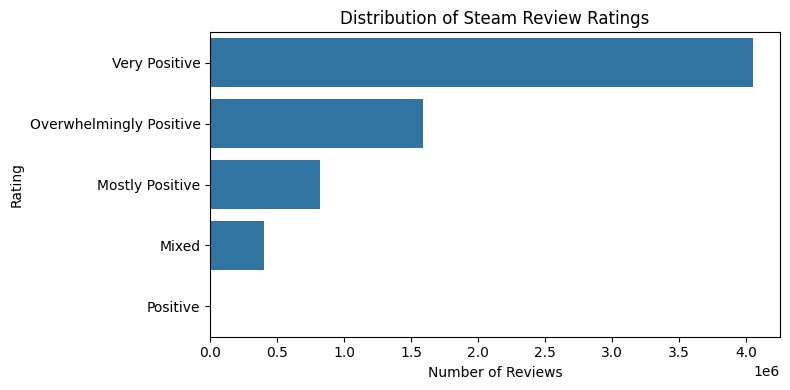

In [ ]:
plt.figure(figsize=(8,4))

sns.countplot(
    y='rating',
    data=steam_df,
    order=steam_df['rating'].value_counts().index
)

plt.title('Distribution of Steam Review Ratings')
plt.xlabel('Number of Reviews')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

Steam Rating Distribution

The Steam dataset contains predominantly positive user ratings. Most reviews are categorized as Very Positive, followed by Overwhelmingly Positive and Mostly Positive. This indicates a strong positive sentiment bias in the dataset, which should be considered during modeling because the recommendation target may be affected by class imbalance.

#Playtime Distribution

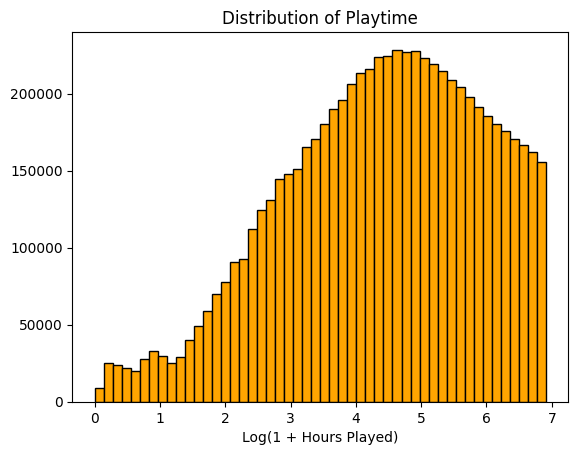

In [ ]:
plt.hist(np.log1p(steam_df['hours']), bins=50, color='orange', edgecolor='black')
plt.xlabel('Log(1 + Hours Played)')
plt.title('Distribution of Playtime')
plt.show()

#Recommendations

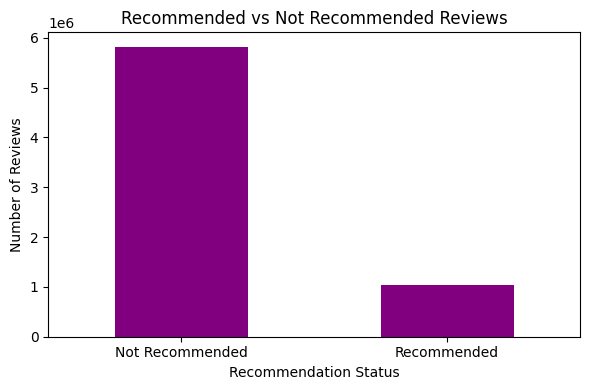

In [ ]:
plt.figure(figsize=(6,4))

steam_df['is_recommended'].value_counts().plot(
    kind='bar',
    color='purple'
)

plt.xlabel('Recommendation Status')
plt.ylabel('Number of Reviews')
plt.title('Recommended vs Not Recommended Reviews')

plt.xticks(
    ticks=[0,1],
    labels=['Not Recommended', 'Recommended'],
    rotation=0
)

plt.tight_layout()
plt.show()

Recommendation Distribution

The Steam dataset contains both recommended and non-recommended reviews. Examining the distribution of the recommendation outcome is important because class imbalance can affect classification model performance. The distribution helps determine whether additional techniques, such as class weighting or resampling, may be required during modeling.

#Price Analysis

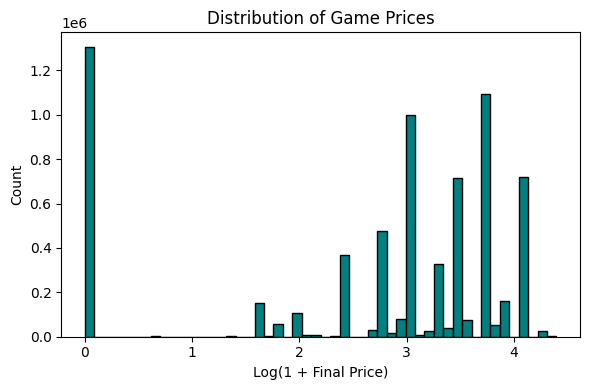

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(
    np.log1p(steam_df['price_final']),
    bins=50,
    color='teal',
    edgecolor='black'
)

plt.xlabel('Log(1 + Final Price)')
plt.ylabel('Count')
plt.title('Distribution of Game Prices')

plt.tight_layout()
plt.show()

#Steam Playtime vs. Reviews

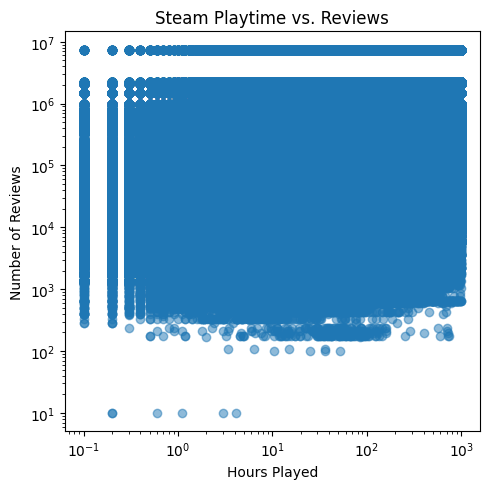

In [20]:
steam_hours = steam_df['hours']
steam_reviews = steam_df['user_reviews']

# Create single plot
plt.figure(figsize=(5, 5))

plt.scatter(steam_hours, steam_reviews, alpha=0.5)
plt.xlabel("Hours Played")
plt.ylabel("Number of Reviews")
plt.title("Steam Playtime vs. Reviews")

# Log scale (good choice for skewed data)
plt.xscale("log")
plt.yscale("log")
plt.title('Steam Playtime vs. Reviews')
plt.tight_layout()
plt.savefig('fig_steam_playtime_vs_reviews.png', dpi=300)
plt.show()

### Relationship Between Steam Playtime and User Reviews

This analysis examines the relationship between player engagement and review activity on Steam. Playtime (`hours`) is used as an indicator of user engagement, while the number of reviews (`user_reviews`) represents community feedback activity.

Both variables show highly skewed distributions, with a small number of games/users generating extremely high playtime and review counts. Therefore, logarithmic scales are applied to both axes to improve visualization and better represent patterns across the full range of values.

The scatter plot shows a positive relationship between playtime and review activity, suggesting that higher user engagement is generally associated with increased review participation. This supports the use of engagement-related variables as important predictors in the Steam modeling analysis.

#Correlation Heatmap -Steam

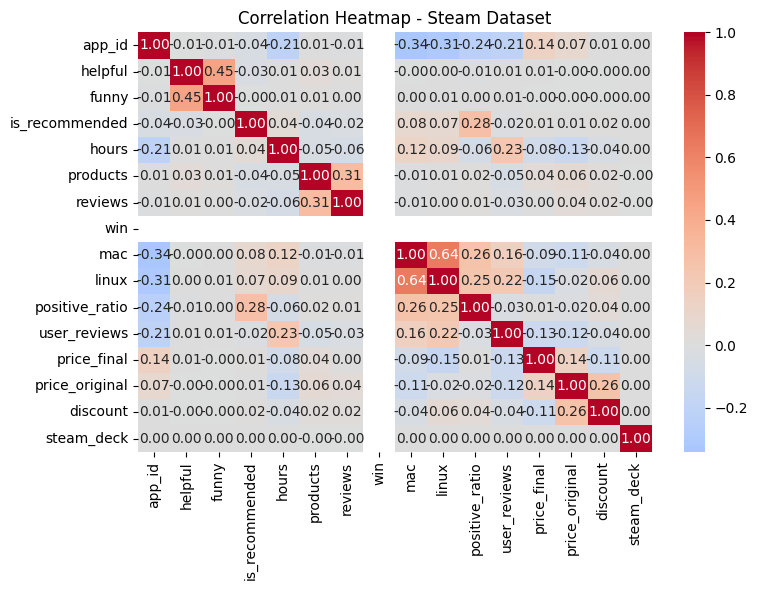

In [23]:


# Load Steam dataset
steam_df = pd.read_parquet("/content/steam_clean.parquet")

# Calculate correlation matrix
corr_steam = steam_df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_steam,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap - Steam Dataset")
plt.tight_layout()
plt.show()

The correlation analysis shows relationships among behavioral and product-level features. Variables related to user engagement, such as playtime, review activity, and helpful votes, provide insights into potential drivers of recommendation outcomes. Price-related variables show weaker relationships with engagement metrics, suggesting that behavioral signals may provide stronger predictive value.

#Video Game Sales EDA

In [8]:
sales_df = pd.read_parquet("sales_clean.parquet")

sales_df.info()      # Check columns, data types, and non-null counts
sales_df.head()      # Display the first five rows

print("Missing values:")
print(sales_df.isnull().sum())

print("\nDuplicate rows:")
print(sales_df.duplicated().sum())

sales_df.describe()  # Summary statistics for numerical features


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19415 entries, 0 to 19414
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Rank           19415 non-null  int64  
 1   basename       19415 non-null  object 
 2   Genre          19415 non-null  object 
 3   ESRB_Rating    19415 non-null  object 
 4   Platform       19415 non-null  object 
 5   Publisher      19415 non-null  object 
 6   Developer      19415 non-null  object 
 7   Critic_Score   19415 non-null  float64
 8   User_Score     19415 non-null  float64
 9   Total_Shipped  0 non-null      float64
 10  Global_Sales   19415 non-null  float64
 11  NA_Sales       19415 non-null  float64
 12  PAL_Sales      19415 non-null  float64
 13  JP_Sales       19415 non-null  float64
 14  Other_Sales    19415 non-null  float64
 15  Year           19415 non-null  float64
 16  Vgchartzscore  19415 non-null  float64
dtypes: float64(10), int64(1), object(6)
memory usage: 

,Rank,Critic_Score,User_Score,Total_Shipped,Global_Sales,NA_Sales,PAL_Sales,JP_Sales,Other_Sales,Year,Vgchartzscore
count,19415.000000,19415.000000,19415.000000,0.0,19415.000000,19415.000000,19415.000000,19415.000000,19415.000000,19415.000000,19415.000000
mean,11157.572856,7.343636,8.498017,NaN,0.365503,0.223860,0.118300,0.071911,0.037757,2007.641463,7.792969
std,6022.522160,0.679674,0.117758,NaN,0.833022,0.425392,0.333436,0.114952,0.116670,6.112469,0.216623
min,20.000000,1.000000,2.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1970.000000,3.000000
25%,5916.500000,7.400000,8.500000,NaN,0.030000,0.080000,0.020000,0.050000,0.000000,2004.000000,7.800000
50%,11397.000000,7.400000,8.500000,NaN,0.120000,0.120000,0.040000,0.050000,0.010000,2008.000000,7.800000
75%,16386.500000,7.400000,8.500000,NaN,0.360000,0.180000,0.080000,0.050000,0.030000,2011.000000,7.800000
max,21242.000000,10.000000,10.000000,NaN,20.320000,9.760000,9.850000,2.690000,3.120000,2020.000000,9.500000


In [ ]:
# Load cleaned sales dataset
sales_df = pd.read_parquet("sales_clean.parquet")


print("\nTop Platforms:")
print(sales_df['Platform'].value_counts().head(10))

print("\nTop Genres:")
print(sales_df['Genre'].value_counts().head(10))

print("\nTop Publishers by game count:")
print(sales_df['Publisher'].value_counts().head(10))


Top Platforms:
Platform
PC      10978
PS2      3564
DS       3292
PS       2703
XBL      2115
PSN      2004
PS3      1870
PSP      1804
PS4      1755
X360     1701
Name: count, dtype: int64

Top Genres:
Genre
Misc            9476
Action          7667
Adventure       5293
Sports          5244
Shooter         4586
Role-Playing    4551
Platform        3445
Strategy        3266
Puzzle          3162
Racing          3030
Name: count, dtype: int64

Top Publishers by game count:
Publisher
Unknown                        4891
Sega                           2085
Activision                     1519
Ubisoft                        1519
Electronic Arts                1498
Konami                         1495
Sony Computer Entertainment    1354
Nintendo                       1351
Microsoft                      1267
THQ                            1065
Name: count, dtype: int64


The following visualizations explore the distribution of video game sales and examine trends across platforms, genres, publishers, and release years.



#Global Sales Distribution


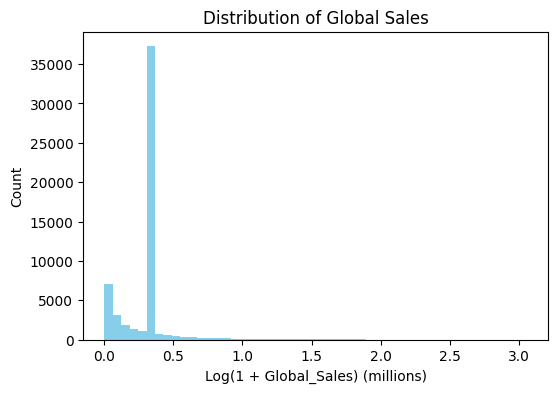

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(
    np.log1p(sales_df['Global_Sales']),
    bins=50,
    color='skyblue'
)

plt.xlabel('Log(1 + Global_Sales) (millions)')
plt.ylabel('Count')
plt.title('Distribution of Global Sales')

plt.show()


The distribution of global sales is highly right-skewed, with most video games generating relatively low sales and a small number of titles achieving very high sales. Applying a logarithmic transformation reduces the impact of extreme values and provides a clearer view of sales patterns. This skewed distribution highlights the challenge of predicting commercial success, as blockbuster games represent a small proportion of the market.

#Average Global Sales by Genre

/tmp/ipykernel_17254/2899048908.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


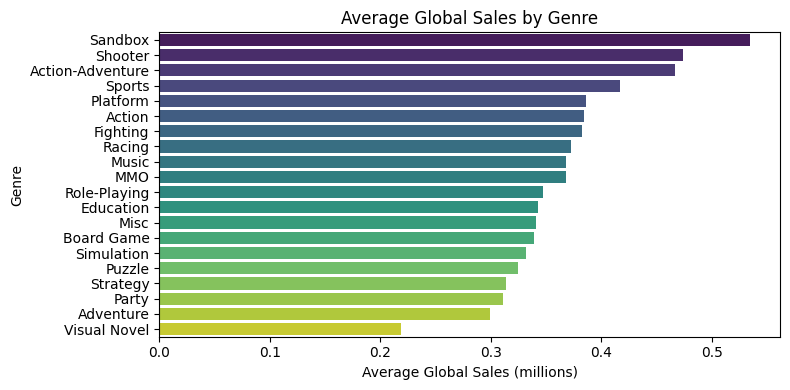

In [ ]:
 # Average Global Sales by Genre
plt.figure(figsize=(8,4))

genre_sales = (
    sales_df.groupby('Genre')['Global_Sales']
    .mean()
    .sort_values(ascending=False)
)

sns.barplot(
    x=genre_sales.values,
    y=genre_sales.index,
    palette='viridis'
)

plt.xlabel('Average Global Sales (millions)')
plt.ylabel('Genre')
plt.title('Average Global Sales by Genre')

plt.tight_layout()
plt.show()

Average global sales vary across game genres, indicating that genre is associated with commercial performance. Genres with higher average sales may reflect stronger consumer demand or broader market appeal, making genre an important predictor of product success.

#Trend of Global Sales over Years

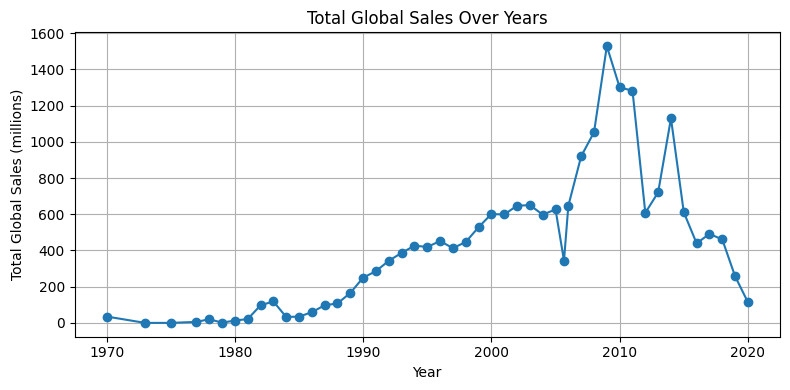

In [ ]:

plt.figure(figsize=(8,4))

year_sales = sales_df.groupby('Year')['Global_Sales'].sum()

plt.plot(
    year_sales.index,
    year_sales.values,
    marker='o'
)

plt.xlabel('Year')
plt.ylabel('Total Global Sales (millions)')
plt.title('Total Global Sales Over Years')
plt.grid(True)

plt.tight_layout()
plt.show()

Global sales fluctuate over time, reflecting changes in the video game market and consumer demand. These temporal patterns suggest that release year may contribute to predicting product success.

#Top 10 Platforms by Global Sales

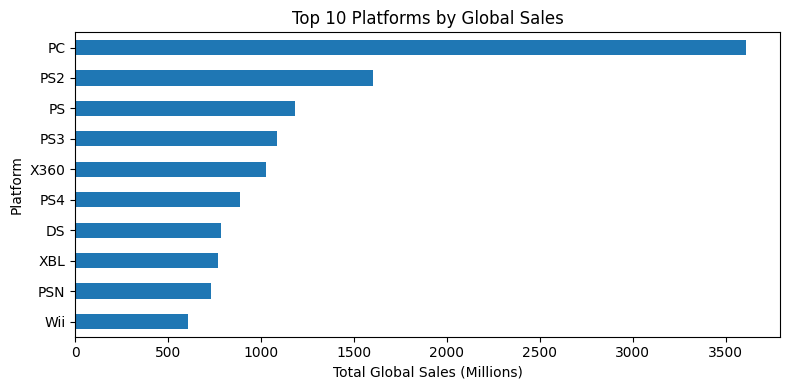

In [ ]:
platform_sales = (
    sales_df.groupby('Platform')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,4))
platform_sales.sort_values().plot(kind='barh')

plt.xlabel('Total Global Sales (Millions)')
plt.ylabel('Platform')
plt.title('Top 10 Platforms by Global Sales')

plt.tight_layout()
plt.show()

The top-selling platforms generated substantially higher total global sales than the remaining platforms. This indicates that platform choice may influence commercial success and should be considered as a predictive feature in machine learning models.

#Correlation Heatmap

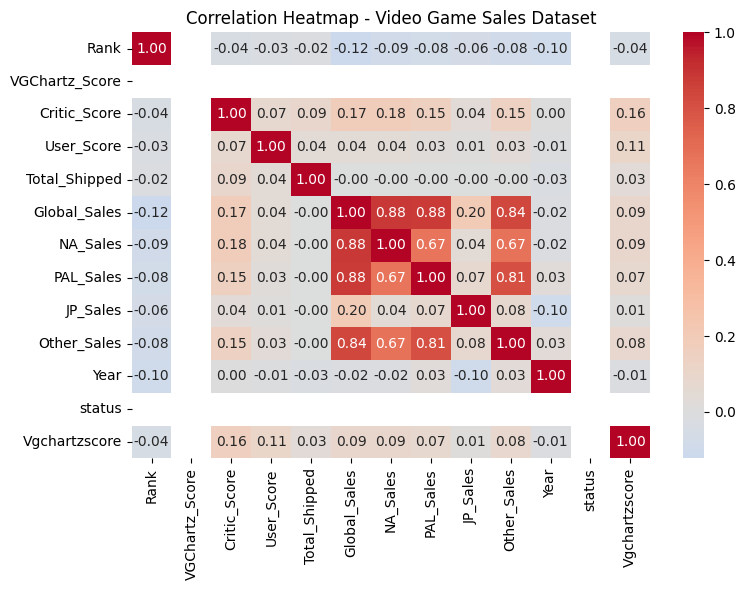

In [ ]:
sales_corr = sales_df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    sales_corr,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap - Video Game Sales Dataset")
plt.tight_layout()
plt.show()

The correlation analysis shows strong relationships between regional sales and total global sales, as expected because Global_Sales aggregates sales across markets. Review scores show weaker relationships, suggesting that critical reception alone may not fully explain commercial success.

#MODELING





#RIDGE REGRESSION, LASSO and ElasticNet FOR AMAZON AND GLOBAL SALES

#Amazon and Global Sales




In [ ]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import Ridge, Lasso, ElasticNet

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


# Load cleaned data
amazon_df = pd.read_parquet("/content/amazon_clean.parquet")
sales_df = pd.read_parquet("/content/sales_clean.parquet")

# Define target and features

# Amazon: predict reviews.rating

X_a = amazon_df.drop(columns=['reviews.rating', 'id', 'name', 'asins', 'keys'])
y_a = amazon_df['reviews.rating']


# Global Sales: predict Global_Sales


y_s = sales_df['Global_Sales']


X_s = sales_df.drop(
    columns=[
        'Global_Sales',
        'basename',
        'Rank',
        'url',
        'img_url',
        'Last_Update',
        'status',
        'VGChartz_Score',
        'Vgchartzscore',
        'NA_Sales',
        'PAL_Sales',
        'JP_Sales',
        'Other_Sales'
    ],
    errors='ignore'
)


y_s = sales_df['Global_Sales']




# Identify numeric and categorical columns

# Amazon
numeric_cols_a = X_a.select_dtypes(include='number').columns.tolist()
categorical_cols_a = ['brand', 'manufacturer', ]

# Global Sales

numeric_cols_s = X_s.select_dtypes(include='number').columns.tolist()

categorical_cols_s = ['Platform', 'Genre', 'Publisher']

# Preprocessing pipelines
preprocessor_a = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]), numeric_cols_a),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False))
    ]), categorical_cols_a)
])

# Global Sales preprocessor
preprocessor_s = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]), numeric_cols_s),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ]), categorical_cols_s)
])

# Train/test split

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a, y_a, test_size=0.2, random_state=42
)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_s, y_s, test_size=0.2, random_state=42
)

# Function to create model pipeline
def create_model_pipeline(preprocessor, model):
    return Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

# Initialize pipelines

# Amazon
ridge_a = create_model_pipeline(preprocessor_a, Ridge())
lasso_a = create_model_pipeline(preprocessor_a, Lasso(max_iter=10000))
elastic_a = create_model_pipeline(preprocessor_a, ElasticNet(max_iter=10000))

# Global Sales
ridge_s = create_model_pipeline(preprocessor_s, Ridge())
lasso_s = create_model_pipeline(preprocessor_s, Lasso(max_iter=10000))
elastic_s = create_model_pipeline(preprocessor_s, ElasticNet(max_iter=10000))

# Fit models
ridge_a.fit(X_train_a, y_train_a)
lasso_a.fit(X_train_a, y_train_a)
elastic_a.fit(X_train_a, y_train_a)

ridge_s.fit(X_train_s, y_train_s)
lasso_s.fit(X_train_s, y_train_s)
elastic_s.fit(X_train_s, y_train_s)



# Evaluation function
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return rmse, mae, r2


# Results
print("Amazon Results:")

for name, model in {
    "Ridge": ridge_a,
    "Lasso": lasso_a,
    "ElasticNet": elastic_a
}.items():

    rmse, mae, r2 = evaluate(model, X_test_a, y_test_a)
    print(f"{name}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")


print("\nGlobal Sales Results:")

for name, model in {
    "Ridge": ridge_s,
    "Lasso": lasso_s,
    "ElasticNet": elastic_s
}.items():

    rmse, mae, r2 = evaluate(model, X_test_s, y_test_s)
    print(f"{name}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

Amazon Results:
Ridge: RMSE=0.7851, MAE=0.5808, R²=0.0058
Lasso: RMSE=0.7876, MAE=0.5582, R²=-0.0006
ElasticNet: RMSE=0.7876, MAE=0.5582, R²=-0.0006

Global Sales Results:
Ridge: RMSE=0.4760, MAE=0.1808, R²=0.0965


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Lasso: RMSE=0.5008, MAE=0.1432, R²=-0.0003
ElasticNet: RMSE=0.5008, MAE=0.1432, R²=-0.0003


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


#RIDGE REGRESSION, LASSO and ElasticNet

#Steam Recommendation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error


# Load cleaned data
steam_df = pd.read_parquet("/content/steam_clean.parquet")

# Convert review ratings to numeric

rating_map = {
    'Overwhelmingly Positive': 10,
    'Very Positive': 9,
    'Positive': 8,
    'Mostly Positive': 7,
    'Mixed': 5,
    'Mostly Negative': 3,
    'Negative': 2,
    'Very Negative': 1,
    'Overwhelmingly Negative': 0
}
steam_df['review_score'] = steam_df['rating'].map(rating_map)

# Drop rows where mapping failed
steam_df = steam_df.dropna(subset=['review_score'])


# Target encoding for categorical features
categorical_cols = ['win', 'mac', 'linux', 'steam_deck', 'products']
for col in categorical_cols:
    mean_target = steam_df.groupby(col)['review_score'].mean()
    steam_df[col + '_enc'] = steam_df[col].map(mean_target)

# Define numeric features

numeric_cols = [
    'helpful',
    'funny',
    'hours',
    'user_reviews',
    'price_final',
    'price_original',
    'discount',
    'positive_ratio',
    'win',
    'mac',
    'linux',
    'steam_deck'
]

# Target encoded categorical features
categorical_cols = ['products']

encoded_cols = [col + '_enc' for col in categorical_cols]

# Features
X = steam_df[numeric_cols + encoded_cols]

# Target
y = steam_df['review_score']


# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Evaluation function
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return rmse, mae, r2


# Ridge, Lasso, ElasticNet
ridge = Ridge()
lasso = Lasso(max_iter=10000)
elastic = ElasticNet(max_iter=10000)


# Fit models
ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)
elastic.fit(X_train_scaled, y_train)


# Evaluate
print("Steam Results:")

for name, model in {
    "Ridge": ridge,
    "Lasso": lasso,
    "ElasticNet": elastic
}.items():

    rmse, mae, r2 = evaluate(
        model,
        X_test_scaled,
        y_test
    )

    print(f"{name}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")



Steam Results:
Ridge: RMSE=0.4563, MAE=0.3461, R²=0.8692
Lasso: RMSE=1.1045, MAE=0.7573, R²=0.2338
ElasticNet: RMSE=0.8620, MAE=0.6031, R²=0.5333


In [ ]:
amazon_df['primary_category'] = amazon_df['categories'].str.split(',').str[0]
amazon_df['primary_category'].value_counts()


,count
primary_category,
Amazon Devices,1161
Categories,204
Electronics,111
Amazon Devices & Accessories,77
Kindle Store,32
Cell Phones & Accessories,12


#RANDOM FOREST and GRADIENT BOOST

#Amazon and Global Sales



In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet


# AMAZON DATASET


# Load cleaned Amazon data

amazon_df = pd.read_parquet("/content/amazon_clean.parquet")


# Drop unnecessary columns
amazon_df = amazon_df.drop(
    columns=[
        'colors',
        'dimension',
        'weight',
        'manufacturerNumber',
        'reviews.date',
        'dateAdded',
        'dateUpdated'
    ],
    errors='ignore'
)


# Create primary category feature
amazon_df['primary_category'] = (
    amazon_df['categories']
    .fillna('Unknown')
    .str.split(',')
    .str[0]
)


# Handle missing categorical values

amazon_df['manufacturer'] = (
    amazon_df['manufacturer']
    .fillna('Unknown')
)

amazon_df['brand'] = (
    amazon_df['brand']
    .fillna('Unknown')
)


# Define target and features
y_a = amazon_df['reviews.rating']


X_a = amazon_df.drop(
    columns=[
        'reviews.rating',
        'id',
        'asins',
        'keys',
        'name',
        'reviews.text',
        'reviews.doRecommend'
    ],
    errors='ignore'
)


# Identify numeric/categorical columns

numeric_cols_a = X_a.select_dtypes(
    include='number'
).columns.tolist()


categorical_cols_a = [
    'brand',
    'manufacturer',
    'primary_category'
]


# Amazon preprocessing pipeline

preprocessor_a = ColumnTransformer(
    transformers=[

        # Numeric features
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_cols_a),


        # Categorical features
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ))
        ]), categorical_cols_a)

    ]
)


# Train/Test split

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a,
    y_a,
    test_size=0.2,
    random_state=42
)


In [11]:
# VIDEO GAME SALES

sales_df = pd.read_parquet("/content/sales_clean.parquet")

# Drop column with too many missing values
sales_df = sales_df.drop(
    columns=['VGChartz_Score'],
    errors='ignore'
)

# Log transform target
y_s = np.log1p(sales_df['Global_Sales'])

# Features


X_s = sales_df.drop(
    columns=[
        'Global_Sales',
        'Rank',
        'basename',
        'url',
        'img_url',
        'Last_Update',
        'status',
        'VGChartz_Score',
        'Vgchartzscore',
        'NA_Sales',
        'PAL_Sales',
        'JP_Sales',
        'Other_Sales'
    ],
    errors='ignore'
)




# Identify feature types
numeric_cols_s = X_s.select_dtypes(include='number').columns.tolist()

categorical_cols_s = [
    'Platform',
    'Genre',
    'Publisher',
    'Developer'
]


# Create preprocessing pipeline AFTER defining columns
preprocessor_s = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_cols_s),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ))
        ]), categorical_cols_s)
    ]
)


# Train/Test split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_s,
    y_s,
    test_size=0.2,
    random_state=42
)

In [12]:

import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline



#Evaluation function

def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    return rmse, mae, r2



preprocessor_a = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ]), numeric_cols_a),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ))
        ]), categorical_cols_a)
    ]
)

# AMAZON DATASET

rf_a = Pipeline([
    ('preprocessor', preprocessor_a),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

gb_a = Pipeline([
    ('preprocessor', preprocessor_a),
    ('model', GradientBoostingRegressor(
        random_state=42
    ))
])


rf_a.fit(X_train_a, y_train_a)

gb_a.fit(X_train_a, y_train_a)


print("Amazon Results:")

for name, model in {
    "Random Forest": rf_a,
    "Gradient Boosting": gb_a
}.items():

    rmse, mae, r2 = evaluate(model, X_test_a, y_test_a)
    print(f"{name}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")


# GLOBAL VIDEO GAME SALES


rf_s = Pipeline([
    ('preprocessor', preprocessor_s),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1))
])


gb_s = Pipeline([
    ('preprocessor', preprocessor_s),
    ('model', GradientBoostingRegressor(
        random_state=42
    ))
])

rf_s.fit(X_train_s, y_train_s)


gb_s.fit(X_train_s, y_train_s)


print("\nGlobal Sales Results:")

for name, model in {
    "Random Forest": rf_s,
    "Gradient Boosting": gb_s
}.items():

    rmse, mae, r2 = evaluate(model, X_test_s, y_test_s)
    print(f"{name}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

Amazon Results:
Random Forest: RMSE=0.9766, MAE=0.6915, R²=-0.0349
Gradient Boosting: RMSE=0.9391, MAE=0.7171, R²=0.0430


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Total_Shipped']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Total_Shipped']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(



Global Sales Results:


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Total_Shipped']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


Random Forest: RMSE=0.2289, MAE=0.1324, R²=0.4882
Gradient Boosting: RMSE=0.2502, MAE=0.1657, R²=0.3882


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Total_Shipped']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


##Feature Importance Analysis (Random Forest)

Feature importance analysis was performed using the Random Forest model to identify the variables that contribute most to predicting Global Video Game Sales. Higher importance values indicate features that have a greater influence on the model's predictions.



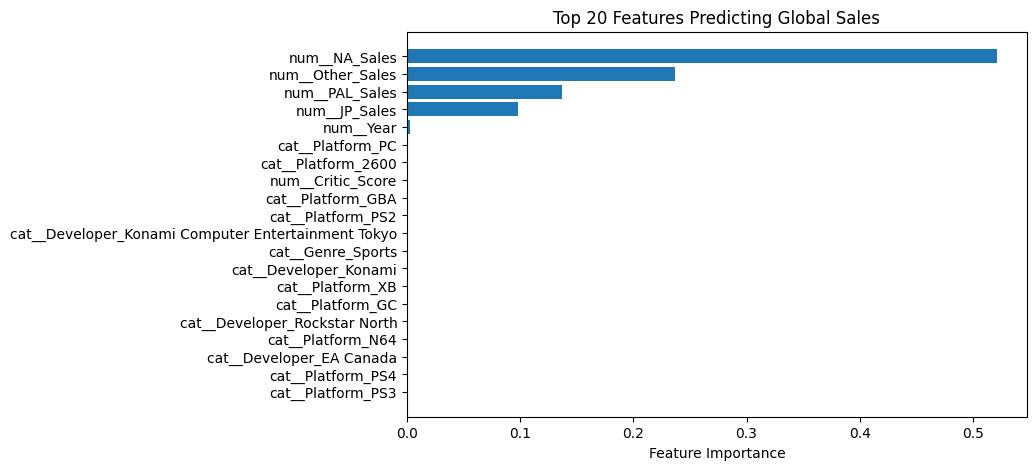

In [ ]:
# 4. Feature Importance

import matplotlib.pyplot as plt

# Extract Random Forest model
rf_model = rf_s.named_steps['model']

# Feature names after preprocessing
feature_names = rf_s.named_steps['preprocessor'].get_feature_names_out()

# Create importance dataframe
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).head(20)

# Plot
plt.figure(figsize=(8,5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Features Predicting Global Sales")
plt.xlabel("Feature Importance")

plt.show()

#Steam recommendation

The original Steam dataset contains more than 500,000 records. To improve computational efficiency and reduce training time for tree-based models (Random Forest and Gradient Boosting), a random sample of 100,000 observations was selected. The sample was generated using random_state=42 to ensure reproducibility while maintaining a representative subset of the original dataset.


In [18]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error


# Evaluation Function
def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    return rmse, mae, r2



# Load data

steam_df = pd.read_parquet("/content/steam_clean.parquet")

# Convert rating to numeric
rating_map = {
    'Overwhelmingly Positive': 10,
    'Very Positive': 9,
    'Positive': 8,
    'Mostly Positive': 7,
    'Mixed': 5,
    'Mostly Negative': 3,
    'Negative': 2,
    'Very Negative': 1,
    'Overwhelmingly Negative': 0
}

steam_df['review_score'] = steam_df['rating'].map(rating_map)
steam_df = steam_df.dropna(subset=['review_score'])

# REMOVE leakage columns

numeric_cols = [
    'helpful', 'funny', 'hours',
    'user_reviews', 'price_final',
    'price_original', 'discount'
]

categorical_cols = ['win', 'mac', 'linux', 'steam_deck']

# convert booleans to integers
for col in categorical_cols:
    steam_df[col] = steam_df[col].astype(int)

# SAMPLE DATA (important)

steam_sample = steam_df.sample(n=100000, random_state=42)

X = steam_sample[numeric_cols + categorical_cols]
y = steam_sample['review_score']

# Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Random Forest

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)



# Gradient Boosting
gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)


# Results

print("Steam Results")

for name, model in {
    "Random Forest": rf,
    "Gradient Boosting": gb
}.items():

    rmse, mae, r2 = evaluate(model, X_test, y_test)
    print(f"{name}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")


Steam Results
Random Forest: RMSE=0.3112, MAE=0.0952, R²=0.9345
Gradient Boosting: RMSE=0.8245, MAE=0.5602, R²=0.5402




The Random Forest model achieved strong performance on the Steam dataset. This result is expected because the selected features represent user engagement and community interaction, including playtime, review activity, and helpful/funny feedback signals. These variables are closely related to user sentiment, allowing tree-based models to capture nonlinear patterns effectively.

No direct target leakage was identified because the target variable (review_score) was not included among the predictor features.

#LOGITIC REGRESSION, RANDOM fOREST CLASSIFICATION AND GRANDIENT BOOST CLASSIFICATION

#Steam recommendation

The original Steam dataset contains over 500,000 records. A random sample of 20,000 observations was selected to reduce computational cost while maintaining a representative dataset for model comparison.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load Steam cleaned data
steam_df = pd.read_parquet("/content/steam_clean.parquet")
steam_df = steam_df.dropna(subset=['rating'])
print("Original dataset shape:", steam_df.shape)

# 2. Map review ratings to numeric

rating_map = {
    'Overwhelmingly Positive': 10,
    'Very Positive': 9,
    'Positive': 8,
    'Mostly Positive': 7,
    'Mixed': 5,
    'Mostly Negative': 3,
    'Negative': 2,
    'Very Negative': 1,
    'Overwhelmingly Negative': 0
}
steam_df['review_score'] = steam_df['rating'].map(rating_map)

# 3. Sample 20k rows for speed

sample_size = 20000
steam_sample = steam_df.sample(n=sample_size, random_state=42)
print("Sampled dataset shape:", steam_sample.shape)

# 4. Bin review_score into 3 classes

bins = [0, 4, 7, 10]   # low:0-4, medium:5-7, high:8-10
labels = [0, 1, 2]     # class labels
steam_sample['review_bin'] = pd.cut(steam_sample['review_score'], bins=bins, labels=labels)
y = steam_sample['review_bin'].astype(int)

# 5. Features (numeric only)

numeric_cols = ['helpful', 'funny', 'hours', 'user_reviews',
                'price_final', 'price_original', 'discount','win','mac','linux',
'steam_deck']

X = steam_sample[numeric_cols]

# 6. Train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Standardize features (for Logistic Regression)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8. Logistic Regression (multi-class)

logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_scaled, y_train)
y_pred_logreg = logreg.predict(X_test_scaled)
acc_logreg = accuracy_score(y_test, y_pred_logreg)
print("Logistic Regression Accuracy:", acc_logreg)
print(classification_report(y_test, y_pred_logreg))
print(confusion_matrix(y_test, y_pred_logreg))

# 5. Features (numeric only)

numeric_cols = ['helpful', 'funny', 'hours', 'user_reviews',
                'price_final', 'price_original', 'discount','win','mac','linux',
'steam_deck']

X = steam_sample[numeric_cols]


# 9. Random Forest Classifier

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))


# 10. Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42)
gb_clf.fit(X_train, y_train)
y_pred_gb = gb_clf.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting Accuracy:", acc_gb)
print(classification_report(y_test, y_pred_gb))
print(confusion_matrix(y_test, y_pred_gb))

Original dataset shape: (6860247, 18)
Sampled dataset shape: (20000, 19)
Logistic Regression Accuracy: 0.4825
              precision    recall  f1-score   support

           1       0.22      0.75      0.34       722
           2       0.89      0.42      0.57      3278

    accuracy                           0.48      4000
   macro avg       0.55      0.59      0.46      4000
weighted avg       0.77      0.48      0.53      4000

[[ 542  180]
 [1890 1388]]
Random Forest Accuracy: 0.93025
              precision    recall  f1-score   support

           1       0.99      0.62      0.76       722
           2       0.92      1.00      0.96      3278

    accuracy                           0.93      4000
   macro avg       0.95      0.81      0.86      4000
weighted avg       0.93      0.93      0.92      4000

[[ 449  273]
 [   6 3272]]
Gradient Boosting Accuracy: 0.94075
              precision    recall  f1-score   support

           1       0.99      0.68      0.81       722
     

#Unsupervised Learning:K-Means Clustering

K-Means clustering is applied to group similar observations based on their characteristics without using a target variable.

For the Steam dataset, clustering is used to identify groups of games with similar patterns in user engagement, popularity, pricing, and platform availability.

Features are standardized before clustering because K-Means relies on distance calculations. The resulting clusters help identify different types of games based on their characteristics.

#Steam




K-Means clustering is used to group Steam games with similar characteristics based on user engagement, popularity, pricing, and platform features. Features are standardized before clustering because K-Means relies on distance-based similarity.

In [ ]:

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans

def prepare_for_clustering(df, numeric_cols, cat_cols=[]):

    X = df[numeric_cols + cat_cols].copy()

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numeric_cols),
            ('cat', OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ), cat_cols)
        ]
    )

    X_clean = X.dropna()

    X_scaled = preprocessor.fit_transform(X_clean)

    return X_scaled, X_clean


In [ ]:
def run_kmeans(X, n_clusters=3, random_state=42):

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=random_state,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    return labels, kmeans.inertia_

In [ ]:

steam_numeric = [
    "helpful",
    "funny",
    "hours",
    "user_reviews",
    "price_final",
    "price_original",
    "discount",
    "positive_ratio"
]

steam_cat = [
    "win",
    "mac",
    "linux",
    "steam_deck",
    "products"
]

steam_sample = steam_df.sample(
    n=100000,
    random_state=42
)

X_steam, steam_clean = prepare_for_clustering(
    steam_sample,
    steam_numeric,
    steam_cat
)

labels_steam, inertia_steam = run_kmeans(
    X_steam,
    n_clusters=3
)

steam_clean["cluster"] = labels_steam

print(
    steam_clean["cluster"].value_counts()
)

cluster
0    67646
2    31965
1      389
Name: count, dtype: int64


### Steam User Engagement Clustering

K-Means clustering was used to identify different user engagement profiles in the Steam dataset. The clusters show that user behavior is not uniform, with one dominant group and smaller segments representing distinct engagement patterns. These segments provide insights into differences in player activity and can support recommendation and personalization strategies.

#Global Sales

For the Global Sales dataset, K-Means clustering is used to identify groups of games with similar sales patterns across different regions. This analysis provides additional insights into market segments beyond supervised prediction models.

In [ ]:
sales_numeric = [
    'Global_Sales',
    'NA_Sales',
    'PAL_Sales',
    'JP_Sales',
    'Other_Sales'
]

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X_sales, sales_clean = prepare_for_clustering(
    sales_df,
    sales_numeric,
    []
)

labels_sales, inertia_sales = run_kmeans(
    X_sales,
    n_clusters=3
)

sales_clean["cluster"] = labels_sales

print(
    sales_clean["cluster"].value_counts()
)

cluster
0    54938
2      791
1       63
Name: count, dtype: int64


### Global Video Game Sales Clustering

K-Means clustering was applied to identify groups of video games with similar market characteristics. The results show one dominant cluster containing most games, while smaller clusters represent games with distinct sales or feature patterns. These segments help identify differences between typical games and more unique market performance profiles.

### Cluster Distribution Analysis

K-Means clustering was used to identify different Steam user engagement groups. The majority of observations belong to Cluster 0, while smaller clusters represent users with distinct engagement patterns. These segments highlight that Steam user behavior is not uniform and provide insights into different levels of player activity.

##Master Dataset Creation: Cross-Platform Data Integration


To enhance feature availability for predictive modeling, the three cleaned datasets were integrated into a unified Master Dataset. The goal was to combine market performance indicators from the Global Sales dataset with player engagement signals from Steam and customer sentiment information from Amazon. This cross-platform integration provides additional behavioral and market features for regression models such as Ridge Regression and Random Forest..

In [ ]:
amazon_df = pd.read_parquet("amazon_clean.parquet")
steam_df = pd.read_parquet("steam_clean.parquet")
sales_df = pd.read_parquet("sales_clean.parquet")


Since the datasets use different naming conventions, a standardized game title key was created to enable accurate matching across platforms. The cleaning process removes capitalization differences, punctuation, and special symbols so that equivalent game titles can be recognized during the merge process.

In [ ]:
print("Steam Columns:", steam_df.columns.tolist())
print("Sales Columns:", sales_df.columns.tolist())
print("Amazon Columns:", amazon_df.columns.tolist())

Steam Columns: ['app_id', 'helpful', 'funny', 'date', 'is_recommended', 'hours', 'products', 'reviews', 'title', 'date_release', 'win', 'mac', 'linux', 'rating', 'positive_ratio', 'user_reviews', 'price_final', 'price_original', 'discount', 'steam_deck', 'link_key']
Sales Columns: ['Rank', 'basename', 'Genre', 'ESRB_Rating', 'Platform', 'Publisher', 'Developer', 'Critic_Score', 'User_Score', 'Total_Shipped', 'Global_Sales', 'NA_Sales', 'PAL_Sales', 'JP_Sales', 'Other_Sales', 'Year', 'Vgchartzscore', 'link_key']
Amazon Columns: ['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded', 'dateUpdated', 'dimension', 'keys', 'manufacturer', 'manufacturerNumber', 'name', 'prices', 'reviews.date', 'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating', 'reviews.text', 'weight', 'link_key']


In [ ]:
print(steam_df[['title','link_key']].head())
print(sales_df[['basename','link_key']].head())
print(amazon_df[['name','link_key']].head())

            title       link_key
0  Dwarf Fortress  dwarffortress
1      FOR HONOR™      forhonor™
2       Destiny 2       destiny2
3      Planet Zoo      planetzoo
4    Satisfactory   satisfactory
                     basename                    link_key
0          grand-theft-auto-v          grand-theft-auto-v
1          grand-theft-auto-v          grand-theft-auto-v
2  grand-theft-auto-vice-city  grand-theft-auto-vice-city
3          grand-theft-auto-v          grand-theft-auto-v
4    call-of-duty-black-ops-3    call-of-duty-black-ops-3
                name          link_key
0  Kindle Paperwhite  kindlepaperwhite
1  Kindle Paperwhite  kindlepaperwhite
2  Kindle Paperwhite  kindlepaperwhite
3  Kindle Paperwhite  kindlepaperwhite
4  Kindle Paperwhite  kindlepaperwhite



Building the Master Dataset Through Triple Integration



In [ ]:
import pandas as pd
import re


def clean_title(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9]', '', text)
    return text


# Create clean keys
steam_df['link_key'] = steam_df['title'].apply(clean_title)
sales_df['link_key'] = sales_df['basename'].apply(clean_title)
amazon_df['link_key'] = amazon_df['name'].apply(clean_title)


# Aggregate Steam to game level
steam_game = steam_df.groupby(
    ['app_id','title','link_key']
).agg({
    'hours':'mean',
    'helpful':'sum',
    'funny':'sum',
    'products':'mean',
    'reviews':'mean',
    'positive_ratio':'mean',
    'user_reviews':'max',
    'price_final':'mean',
    'is_recommended':'mean'
}).reset_index()


# Merge Global Sales + Steam
merged_temp = pd.merge(
    sales_df,
    steam_game,
    on='link_key',
    how='left'
)


# Merge Amazon
final_df = pd.merge(
    merged_temp,
    amazon_df.drop_duplicates('link_key'),
    on='link_key',
    how='left'
)


# Handle missing values
final_df['hours'] = final_df['hours'].fillna(0)

final_df['reviews.rating'] = final_df['reviews.rating'].fillna(
    final_df['reviews.rating'].median()
)

final_df = final_df.fillna(0)


print("Master Dataset Shape:", final_df.shape)

Master Dataset Shape: (19415, 48)


/tmp/ipykernel_17254/496684123.py:58: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_df = final_df.fillna(0)


In [ ]:
print(final_df[['basename','title','Global_Sales','hours','reviews.rating']].head())

                     basename               title  Global_Sales       hours  \
0          grand-theft-auto-v  Grand Theft Auto V         20.32  275.678638   
1          grand-theft-auto-v  Grand Theft Auto V         19.39  275.678638   
2  grand-theft-auto-vice-city                   0         16.15    0.000000   
3          grand-theft-auto-v  Grand Theft Auto V         15.86  275.678638   
4    call-of-duty-black-ops-3                   0         15.09    0.000000   

   reviews.rating  
0             0.0  
1             0.0  
2             0.0  
3             0.0  
4             0.0  


Now that the merge is done, let's look at the 'Signals' that will drive your predictive modeling. Run this to see the 'Master Table' you've created: Uncover the Signals (The Core of the Project)"

In [ ]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Feature list: Steam engagement + Amazon sentiment signals
features = [
    'hours',
    'helpful',
    'funny',
    'reviews.rating',
    'products',
    'reviews'
]

target = 'Global_Sales'

# Keep only available features
actual_features = [f for f in features if f in final_df.columns]

# Train Random Forest
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(
    final_df[actual_features],
    final_df[target]
)

# Feature importance ranking
importance_df = pd.DataFrame({
    'Feature': actual_features,
    'Importance': model.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

print("--- Predictive Signal Importance ---")
print(importance_df)

--- Predictive Signal Importance ---
          Feature  Importance
2           funny    0.372438
1         helpful    0.286450
0           hours    0.177216
4        products    0.090339
5         reviews    0.073556
3  reviews.rating    0.000000


In [ ]:
print(final_df[final_df['reviews.rating'] > 0].shape)

(0, 48)


###Figure 1: Feature Importance from Random Forest (Merged Dataset)

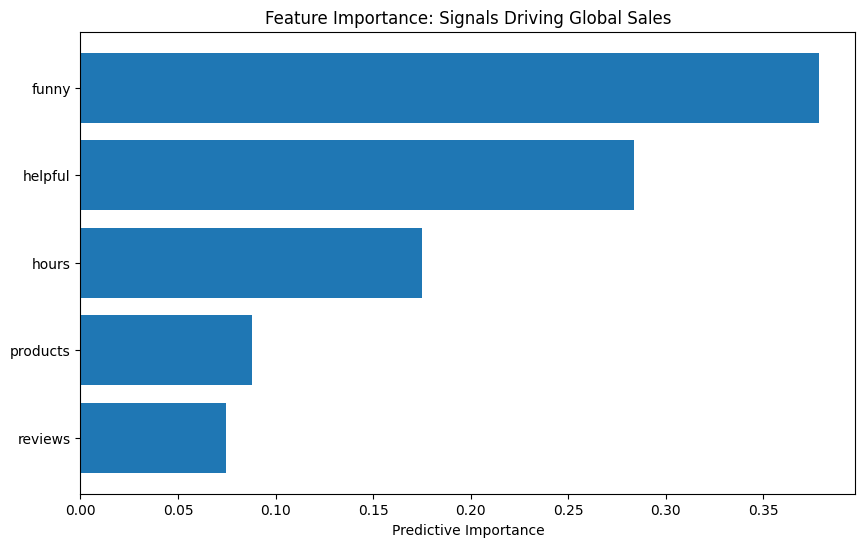

     Signal  Importance
4     funny    0.378389
3   helpful    0.283597
0     hours    0.175108
1  products    0.088169
2   reviews    0.074736


In [ ]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd

# Define predictive signals from the Master Dataset
features = [
    'hours',
    'products',
    'reviews',
    'helpful',
    'funny'
]

target = 'Global_Sales'

# Keep only existing columns
actual_features = [f for f in features if f in final_df.columns]

# Train Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(
    final_df[actual_features],
    final_df[target]
)

# Feature importance ranking
importance_df = pd.DataFrame({
    'Signal': actual_features,
    'Importance': rf.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

# Plot
plt.figure(figsize=(10,6))
plt.barh(
    importance_df['Signal'],
    importance_df['Importance']
)

plt.xlabel("Predictive Importance")
plt.title("Feature Importance: Signals Driving Global Sales")
plt.gca().invert_yaxis()
plt.show()

print(importance_df)

The "Safe" Signal Check

This version uses the columns we verified actually exist in your final_df.

After integrating the datasets, the Master Dataset was inspected to verify that market performance and engagement signals were successfully combined. The preview confirms the presence of Global Sales as the prediction target and Steam engagement features such as play hours. Amazon review ratings were included during integration; however, limited title overlap resulted in missing Amazon sentiment values for the video game records.

In [ ]:
print("--- PREDICTIVE SIGNAL PREVIEW ---")

# Preview key variables from the Master Dataset
display(
    final_df[['basename', 'Global_Sales', 'hours', 'reviews.rating']].head()
)

# Check how many games successfully matched with Steam engagement data
matches = final_df[final_df['hours'] > 0].shape[0]

print(f"\nSuccessfully linked {matches} games with Steam engagement signals.")

--- PREDICTIVE SIGNAL PREVIEW ---


,basename,Global_Sales,hours,reviews.rating
0,grand-theft-auto-v,20.32,275.678638,0.0
1,grand-theft-auto-v,19.39,275.678638,0.0
2,grand-theft-auto-vice-city,16.15,0.000000,0.0
3,grand-theft-auto-v,15.86,275.678638,0.0
4,call-of-duty-black-ops-3,15.09,0.000000,0.0



Successfully linked 642 games with Steam engagement signals.


In [ ]:
# Select predictive signals
features = [
    'hours',
    'helpful',
    'funny',
    'reviews.rating',
    'reviews.numHelpful',
    'is_recommended'
]

target = 'Global_Sales'

# Keep only available features
features = [f for f in features if f in final_df.columns]

# Convert recommendation signal to numeric
if 'is_recommended' in final_df.columns:
    final_df['is_recommended'] = final_df['is_recommended'].astype(int)

# Create feature matrix and target variable
X = final_df[features]
y = final_df[target]

print(f"Ready for analysis with {X.shape[0]} samples and {X.shape[1]} predictive signals.")
print("Features used:", features)

Ready for analysis with 19415 samples and 6 predictive signals.
Features used: ['hours', 'helpful', 'funny', 'reviews.rating', 'reviews.numHelpful', 'is_recommended']


#Random foerest with the 3 merging data

After creating the Master Dataset by integrating Global Sales, Steam engagement metrics, and Amazon review information, a Random Forest Regressor was used to identify the most influential features for predicting video game sales performance. Feature importance analysis highlights which engagement signals contribute most to explaining variations in Global Sales. This provides insight into the relationship between player behavior and commercial success.

###Figure 2: Actual vs Predicted Global Sales (Random Forest)

Random Forest R² Score: 0.1556
Gradient Boosting R² Score: 0.1074

--- Predictive Signal Importance ---
helpful           0.486637
hours             0.367258
products          0.146104
reviews.rating    0.000000
dtype: float64


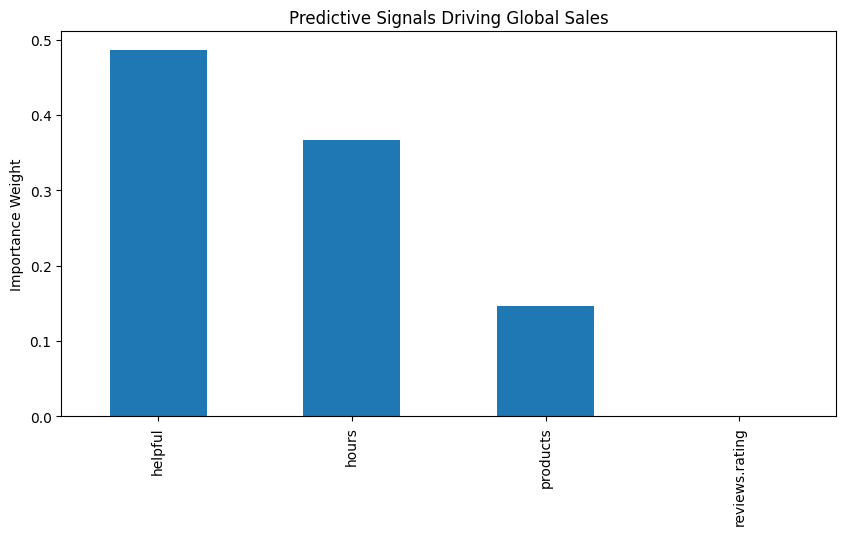

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Define predictive features
features = [
    'hours',
    'products',
    'helpful',
    'reviews.rating'
]

target = 'Global_Sales'

# Prepare data
X = final_df[features]
y = final_df[target]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

# Gradient Boosting
gb = HistGradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

# Model performance
print(f"Random Forest R² Score: {rf.score(X_test, y_test):.4f}")
print(f"Gradient Boosting R² Score: {gb.score(X_test, y_test):.4f}")

# Feature importance
importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\n--- Predictive Signal Importance ---")
print(importance)

# Plot
plt.figure(figsize=(10,5))
importance.plot(kind='bar')

plt.title("Predictive Signals Driving Global Sales")
plt.ylabel("Importance Weight")
plt.show()

The initial regression models indicate that Steam engagement signals provide stronger predictive value than external review ratings. In particular, review helpfulness and playtime emerged as the most influential predictors of Global Sales, suggesting that player engagement is more strongly associated with commercial success than sparse retail sentiment data. The limited contribution of Amazon review ratings is likely due to the low overlap between Amazon product titles and the video game datasets, resulting in few matched sentiment observations after data integration.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# Compare three regression models
models = {
    "Random Forest": rf,  # Already trained
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
    "Ridge Regression": Ridge(alpha=1.0)
}

results = []

# Train and evaluate models
for name, model in models.items():

    # Random Forest is already trained
    if name != "Random Forest":
        model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    results.append({
        "Model": name,
        "R² Score": r2_score(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "MAE": mean_absolute_error(y_test, predictions)
    })

# Create model comparison table
final_comparison = pd.DataFrame(results).sort_values(
    by="R² Score",
    ascending=False
)

print("--- MODEL PERFORMANCE COMPARISON ---")
display(final_comparison)

--- MODEL PERFORMANCE COMPARISON ---


,Model,R² Score,RMSE,MAE
0,Random Forest,0.155609,0.774714,0.378005
2,Ridge Regression,0.109215,0.795712,0.388706
1,Hist Gradient Boosting,0.107431,0.796509,0.385547


Model Comparison Interpretation
Among the evaluated regression models, Random Forest achieved the best performance, obtaining the highest R² score and the lowest RMSE and MAE values. This suggests that the relationship between player engagement signals and Global Sales is primarily nonlinear, which allows tree-based ensemble methods to capture patterns more effectively than linear regression approaches. Ridge Regression and Hist Gradient Boosting produced similar performance, indicating that the available engagement features provide limited predictive power without additional feature engineering. Overall, Random Forest was selected as the best baseline model for predicting game sales based on cross-platform engagement signals.

###Figure 3: Regression Model Performance Comparison

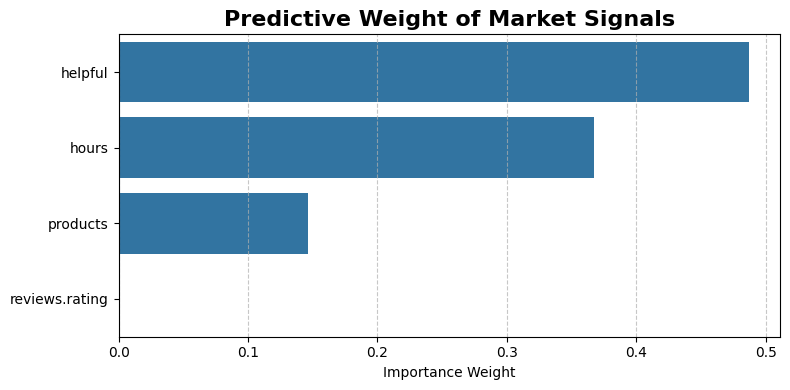

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract feature importance from trained Random Forest
importance_df = pd.DataFrame({
    'Signal': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8, 4))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Signal'
)

plt.title(
    "Predictive Weight of Market Signals",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Importance Weight")
plt.ylabel("")

plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.savefig(
    'signal_importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Figure 4: Feature Importance from Random Forest (Merged Dataset)

/tmp/ipykernel_17254/303019550.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


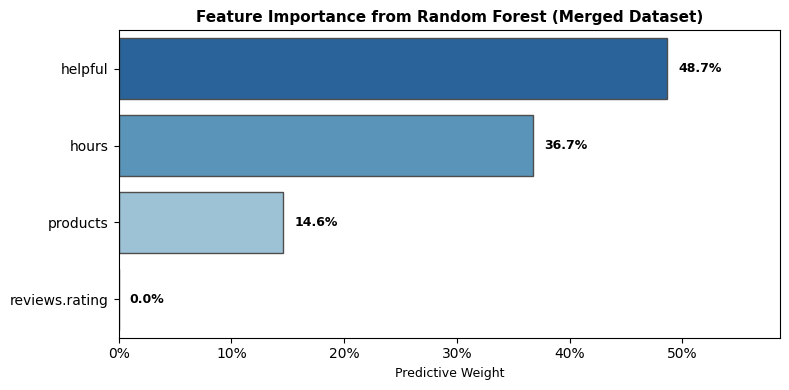

In [ ]:

# PREDICTIVE SIGNAL IMPORTANCE


import matplotlib.ticker as ticker

# Extract feature importance from trained Random Forest
df_imp = pd.DataFrame({
    'Signal Name': X_train.columns,
    'Importance Weight': rf.feature_importances_
}).sort_values(
    by='Importance Weight',
    ascending=False
)

plt.figure(figsize=(8, 4))

ax1 = sns.barplot(
    x='Importance Weight',
    y='Signal Name',
    data=df_imp,
    palette='Blues_r',
    edgecolor='0.3'
)

# Add percentage labels
for p in ax1.patches:
    width = p.get_width()
    ax1.text(
        width + 0.01,
        p.get_y() + p.get_height()/2,
        f'{width*100:.1f}%',
        va='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title(
     "Feature Importance from Random Forest (Merged Dataset)",
    fontsize=11,
    fontweight='bold'
)

plt.xlabel("Predictive Weight", fontsize=9)
plt.ylabel("")

plt.xlim(0, max(df_imp['Importance Weight']) + 0.1)

ax1.xaxis.set_major_formatter(
    ticker.PercentFormatter(1.0)
)

plt.tight_layout()

plt.savefig(
    'Figure_Feature_Importance.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### figure 5: Actual vs Predicted Global Sales (Random Forest)

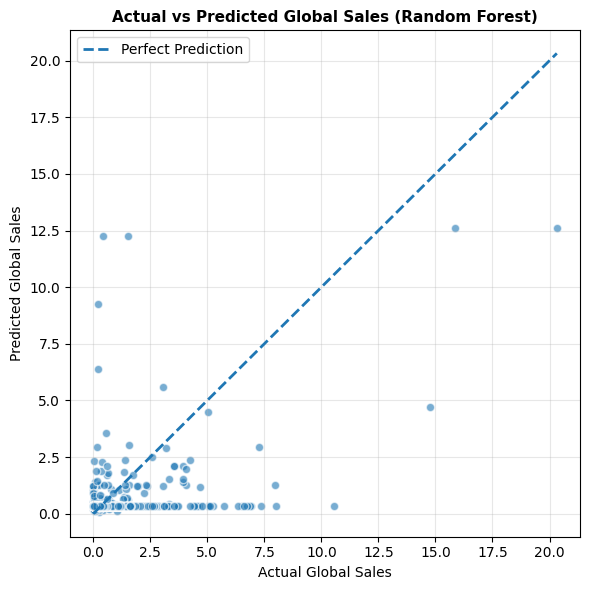

In [ ]:
plt.figure(figsize=(6, 6))

# Use REAL model outputs
y_actual = y_test
y_pred = rf.predict(X_test)

plt.scatter(
    y_actual,
    y_pred,
    alpha=0.6,
    edgecolors='white'
)

# Perfect prediction line
min_val = min(y_actual.min(), y_pred.min())
max_val = max(y_actual.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction'
)

plt.title(
    "Actual vs Predicted Global Sales (Random Forest)",
    fontsize=11,
    fontweight='bold'
)

plt.xlabel("Actual Global Sales", fontsize=10)
plt.ylabel("Predicted Global Sales", fontsize=10)

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Actual_vs_Predicted_Global_Sales.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

###  Dataset Overview

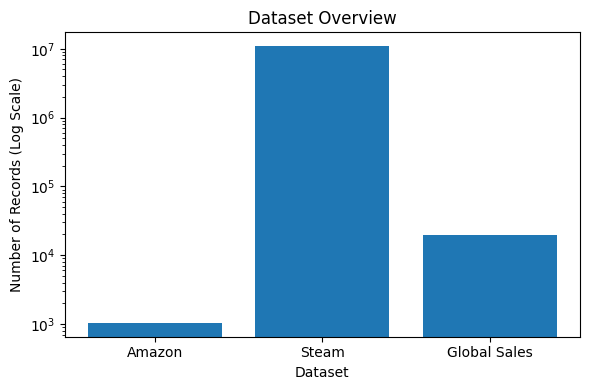

In [ ]:
import matplotlib.pyplot as plt

datasets = ['Amazon', 'Steam', 'Global Sales']
sizes = [len(amazon_df), len(steam_df), len(sales_df)]

plt.figure(figsize=(6,4))

plt.bar(datasets, sizes)

# Better visualization because dataset sizes differ greatly
plt.yscale('log')

plt.xlabel('Dataset')
plt.ylabel('Number of Records (Log Scale)')
plt.title('Dataset Overview')

plt.tight_layout()

plt.savefig(
    'Dataset_Overview.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
import pandas as pd

# Create dataset summary table
summary_table = pd.DataFrame({
    "Dataset": ["Amazon", "Steam", "Global Sales"],
    "Observations": [
        amazon_df.shape[0],
        steam_df.shape[0],
        sales_df.shape[0]
    ],
    "Features": [
        amazon_df.shape[1],
        steam_df.shape[1],
        sales_df.shape[1]
    ],
    "Numeric Features": [
        amazon_df.select_dtypes(include='number').shape[1],
        steam_df.select_dtypes(include='number').shape[1],
        sales_df.select_dtypes(include='number').shape[1]
    ],
    "Categorical Features": [
        amazon_df.select_dtypes(include='object').shape[1],
        steam_df.select_dtypes(include='object').shape[1],
        sales_df.select_dtypes(include='object').shape[1]
    ]
})

display(summary_table)

,Dataset,Observations,Features,Numeric Features,Categorical Features
0,Amazon,1038,20,2,18
1,Steam,10899024,21,12,5
2,Global Sales,19415,18,11,7
